# Recreation of Figure 1 of Schultz et al. (1997)

The central claim of the seminal paper _A Neural Substrate of Prediction and Reward_, authored by Wolfram Schultz, Peter Dayan, and P. Read Montague, is that dopamine neurons do not code for the occurrence of rewards. Instead, dopamine neurons code for an error between the predicted and actual time and magnitude of a reward. 

This notebook aims to reproduce the first figure found in the paper, which models a pattern observed by the researchers when allowing a monkey to gain access to a reward of juice (unconditioned stimulus) by pressing a lever following exposure to a light cue (conditioned stimulus):

1. Before learning, there was a positive error at reward delivery in the monkey's dopamine neuron.
2. After learning, there was no error during the reward delivery, and there was now a positive error during the cue, which the monkey now perceives as a reward-predicting stimulus.
3. After learning, if the reward failed to occur, a positive error would still occur during the cue, but a negative error of roughly equal magnitude would occur when the reward was expected.

In essence, the level of surprise that the monkey had for receiving juice shifted from the moment they received the juice, to the moment they received a cue they had learned to associate with receiving the juice, at an earlier point in time.

Trial | Casual Language | Surprise (Prediction Error)
--|--|--
Monkey receives juice unexpectedly; naive before training | "Didn't see that coming" | +
Monkey expects juice after light cue training and receives it | "Just as I thought" | 0
Monkey expects juice after light cue training but does not receive it | "Where's the juice?" | -


# Reward vs. Value

In Sutton & Barto's text _Reinforcement Learning: An Introduction_, the authors make a distinction in their definitions of "reward" and "value". 

A reward signal is defined as an immediate reward, and is denoted in Schultz et al. (1997) by $$r(t)$$


A value is defined by Sutton & Barto as an expected total future reward, and is denoted in Schultz et al. (1997) by $$V(t)$$

Given that the brain never is able to perfectly calculate $V$, we denote $\hat{V}$ as the estimated value. 

Also note that $t\in\mathbb{Z}^+_0=\{0, 1, 2, \dots\}$ which denotes steps in a given trial, rather than continuous seconds.

When the monkey is exposed to light after training, the monkey updates their prediction about a future reward, rather than immediately receiving the reward itself. That is, $$r(t)=0, \hat{V}(t) >> \hat{V}(t-1)$$ where $t$ is the step where the light cue occurs in the trial.

# Introduction to Temporal Difference (TD) Learning

Temporal difference (TD) learning computes the expectation of future reward, $\hat{V}(t)$, given the prediction of a future reward in the next step, $\hat{V}(t+1)$, along with the current reward: $$\hat{V}(t)=E[r(t) + \gamma \hat{V}(t+1)]$$

where $\gamma$ is **?**

The beauty of this approach is that you can measure expectation before the reward actually comes. Compared to other reinforcement learning (RL) methods that re-compute the expectation of future reward at the very end of every trial, TD learning computes an approximation at every _step_ in a given trial.

That is, the monkey can have a reasonable expectation, due to its dopamine neurons, about when the juice is coming before it has even arrived. After training, they don't have to wait until the end of every trial, whether juice came or not, to improve their juice expectations.

# Introduction to TD Error

TD error is the difference between the current reward plus the expected reward in the next time step, minus the expected reward in the current step, and is denoted: $$\delta(t) = r(t) + \gamma\hat{V}(t+1)-\hat{V}(t)$$

In the context of Schultz's experiment:

Trial | $r$ | $\hat{V}(t+1)$ | $\hat{V}(t)$ | $$\delta(t)$$
--|--|--|--|--
Monkey receives juice unexpectedly; naive before training | $1$ |  $\approx 0$ | $\approx 0$| $1 + 0 - 0 = 1$
Monkey expects juice after light cue training and receives it | $1$ | $\approx 0$ | $\approx 1$ | $1 + 0 - 1 = 0$
Monkey expects juice after light cue training but does not receive it | $0$ | $\approx 0$ | $\approx 1$ | $0 + 0 - 1 = -1$ 

# Representation of Cues and Weights

As previously mentioned, the expected future reward term in the TD learning algorithm is theoretically understood as: $$\hat{V}(t)=E[r(t) + \gamma \hat{V}(t+1)]$$ but is in implemented in Schultz et al. (1997) as: $$\hat{V}(t)=\hat{V}(x(t))=\sum_iw_ix_i(t)$$ where $$\Delta w_i=\alpha\sum_tx_i(t)\delta(t)$$ where 

- $\alpha_k$ is the learning rate
- $x_i(t) = \begin{cases}1 & t=s+i \\ 0 & \text{otherwise}\end{cases}$ is a feature of the complete serial-compound stimulus representation $x(t)$ at delay $i=1,2,\dots,50$, each with its own weight $w_i$
- $t$ is the time step
- $s$ is the moment of the cue

# The Experiment

To replicate the first figure found in Schultz et al. (1997), we will create an experiment where we have one cue, one reward, and an 80-step duration. We observe only three trials (following many trials conducted for training) in which we'll observe TD error across different points in the learner's training.

The light cue occurs at step $t=10$. The size of the reward is $1$, and it occurs at step $t=60$. These numbers come from the third figure of the paper, though that figure is outside the scope of this notebook.  

We'll probe the task prior to any cue-reward training, naively giving the learner the reward. Then we'll probe the task after training while still giving a reward. Finally, we will probe the task after training while withholding the reward.

In order for the computations in our experiment to not be deterministic, I will model several types of non-determinism:

| Type of Non-determinism | What it modifies
|--|--
the juice volume varies | the task
the reward is sometimes omitted during some unobserved training trials | the task
weights are initialized randomly | the learner
basal firing rate of the neuron | the learner





/var/folders/_v/8m4l0w_n1k3g8zrslbv4gz840000gn/T/ipykernel_27961/392069126.py:41: RuntimeWarning: divide by zero encountered in matmul
  expected_future_reward_curr = stimulus_features @ weights
/var/folders/_v/8m4l0w_n1k3g8zrslbv4gz840000gn/T/ipykernel_27961/392069126.py:41: RuntimeWarning: overflow encountered in matmul
  expected_future_reward_curr = stimulus_features @ weights
/var/folders/_v/8m4l0w_n1k3g8zrslbv4gz840000gn/T/ipykernel_27961/392069126.py:41: RuntimeWarning: invalid value encountered in matmul
  expected_future_reward_curr = stimulus_features @ weights
/var/folders/_v/8m4l0w_n1k3g8zrslbv4gz840000gn/T/ipykernel_27961/392069126.py:51: RuntimeWarning: divide by zero encountered in matmul
  weights_delta = alpha * (stimulus_features.T @ td_error)
/var/folders/_v/8m4l0w_n1k3g8zrslbv4gz840000gn/T/ipykernel_27961/392069126.py:51: RuntimeWarning: overflow encountered in matmul
  weights_delta = alpha * (stimulus_features.T @ td_error)
/var/folders/_v/8m4l0w_n1k3g8zrslbv4gz84

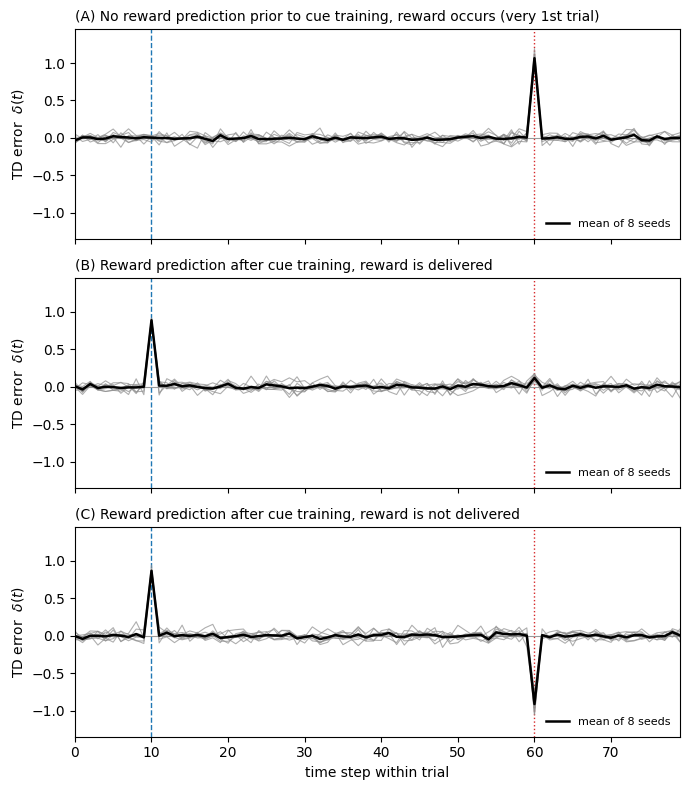

naive @ reward         +1.064 ± 0.065
trained @ cue          +0.889 ± 0.021
trained @ reward       +0.118 ± 0.047
omission @ reward      -0.914 ± 0.103


In [ ]:
import numpy as np

TOTAL_STEPS = 80        # t
LIGHT_CUE_STEP = 10     # s = 10
REWARD_STEP = 60        # s = 60
NUM_DELAYS = 50
ALPHA = 0.1
GAMMA = 1.0

def make_reward_signal(
    total_steps=TOTAL_STEPS, 
    reward_step=REWARD_STEP, 
    deliver=True, 
    amount=1.0
):
    reward_signal = np.zeros(total_steps)
    if deliver:
        reward_signal[reward_step] = amount
    return reward_signal

def make_stimulus_features(
    total_steps=TOTAL_STEPS,
    cue_step=LIGHT_CUE_STEP,
    num_delays=NUM_DELAYS
):
    stimulus_features = np.zeros((total_steps, num_delays))
    for delay_index in range(num_delays):
        activation_step = cue_step + delay_index + 1
        if activation_step < total_steps:
            stimulus_features[activation_step, delay_index] = 1.0
    return stimulus_features

def trial_with_fixed_weights(
    weights,
    reward_signal,
    stimulus_features,
    alpha=ALPHA,
    gamma=GAMMA,
    terminal_estimated_value=0.0
):
    expected_future_reward_curr = stimulus_features @ weights
    expected_future_reward_next = np.zeros(len(expected_future_reward_curr) + 1)
    expected_future_reward_next = np.concatenate(
        [expected_future_reward_curr[1:], [terminal_estimated_value]]
    )
    td_error = (
        reward_signal 
        + gamma * expected_future_reward_next
        - expected_future_reward_curr
    )
    weights_delta = alpha * (stimulus_features.T @ td_error)
    return expected_future_reward_curr, td_error, weights_delta

import matplotlib.pyplot as plt

NUM_TRAINING_STEPS = 650
NAIVE = "pre-training with reward"
TRAINED = "post-training with reward"
OMISSION = "post-training without reward"

def train_and_probe(
    stimulus_features,
    alpha=ALPHA,
    gamma=GAMMA,
    num_trials=NUM_TRAINING_STEPS,
    seed=0,
    p_reward_omission=0.0,
    reward_sd=0.0,
    weight_init_sd=0.0,
    report_noise_sd=0.0
):
    rng = np.random.default_rng(seed)
    weights = (
        rng.normal(0.0, weight_init_sd, NUM_DELAYS)
        if weight_init_sd
        else np.zeros(NUM_DELAYS)
    )
    td_errors = np.zeros((num_trials, TOTAL_STEPS))
    for trial in range(num_trials):
        reward_omission_condition = trial > 0 and rng.random() < p_reward_omission
        reward_delivery_condition = not reward_omission_condition
        if reward_omission_condition:
            amount = 0.0
            reward_signal = make_reward_signal(deliver=False, amount=amount)
        elif reward_delivery_condition:
            amount = 1.0 + reward_sd * rng.standard_normal()
            reward_signal = make_reward_signal(deliver=True, amount=amount)
        _, td_error, weights_delta = trial_with_fixed_weights(
            weights, 
            reward_signal, 
            stimulus_features, 
            alpha, 
            gamma
        )
        td_errors[trial] = td_error + report_noise_sd * rng.standard_normal(TOTAL_STEPS)
        weights = weights + weights_delta
    
    def reward_delivered(deliver):
        reward_signal = make_reward_signal(deliver=deliver)
        _, td_error, _ = trial_with_fixed_weights(weights, reward_signal, stimulus_features, alpha, gamma)
        return td_error + report_noise_sd * rng.standard_normal(TOTAL_STEPS)
    
    return {
        NAIVE: td_errors[0],
        TRAINED: reward_delivered(True),
        OMISSION: reward_delivered(False),
        "weights": weights
    }

SEEDS = range(8)
NOISE = {
    "reward_sd": 0.15,
    "p_reward_omission": 0.1,
    "weight_init_sd": 0.01,
    "report_noise_sd": 0.05
}


stimulus_features = make_stimulus_features()
runs = [
    train_and_probe(stimulus_features, seed=s, **NOISE)
    for s in SEEDS
]

PANEL_TITLES = [
    "(A) No reward prediction prior to cue training, reward occurs (very 1st trial)",
    "(B) Reward prediction after cue training, reward is delivered",
    "(C) Reward prediction after cue training, reward is not delivered",
]
PANEL_KEYS = [NAIVE, TRAINED, OMISSION]


def mark_trial_events(ax):
    """Cue and reward time markers, shared by every figure in this notebook."""
    ax.axvline(LIGHT_CUE_STEP, color="tab:blue", ls="--", lw=1, zorder=0)
    ax.axvline(REWARD_STEP, color="tab:red", ls=":", lw=1, zorder=0)


def plot_td_error_traces(runs, titles=PANEL_TITLES, keys=PANEL_KEYS, figsize=(7, 8)):
    """One panel per Fig. 1 case: per-seed TD error traces plus their mean."""
    fig, axes = plt.subplots(len(keys), 1, figsize=figsize, sharex=True, sharey=True)

    for ax, title, key in zip(axes, titles, keys):
        traces = np.array([run[key] for run in runs])
        ax.axhline(0, color="0.6", lw=0.8)
        mark_trial_events(ax)
        for trace in traces:
            ax.plot(trace, color="0.55", lw=0.8, alpha=0.7)
        ax.plot(traces.mean(0), color="k", lw=1.8, label=f"mean of {len(runs)} seeds")
        ax.set_title(title, loc="left", fontsize=10)
        ax.set_ylabel(r"TD error  $\delta(t)$")
        ax.set_xlim(0, TOTAL_STEPS - 1)
        ax.set_ylim(-1.35, 1.45)
        ax.legend(loc="lower right", fontsize=8, frameon=False)

    axes[-1].set_xlabel("time step within trial")
    fig.tight_layout()
    return fig, axes

fig, axes = plot_td_error_traces(runs)
plt.show()

readouts = {
    "naive @ reward": [
        run["pre-training with reward"][REWARD_STEP] for run in runs
    ],
    "trained @ cue": [
        run["post-training with reward"][LIGHT_CUE_STEP] for run in runs
    ],
    "trained @ reward": [
        run["post-training with reward"][REWARD_STEP] for run in runs
    ],
    "omission @ reward": [
        run["post-training without reward"][REWARD_STEP] for run in runs
    ],
}
for name, vals in readouts.items():
    print(f"{name:22s} {np.mean(vals):+.3f} ± {np.std(vals):.3f}")


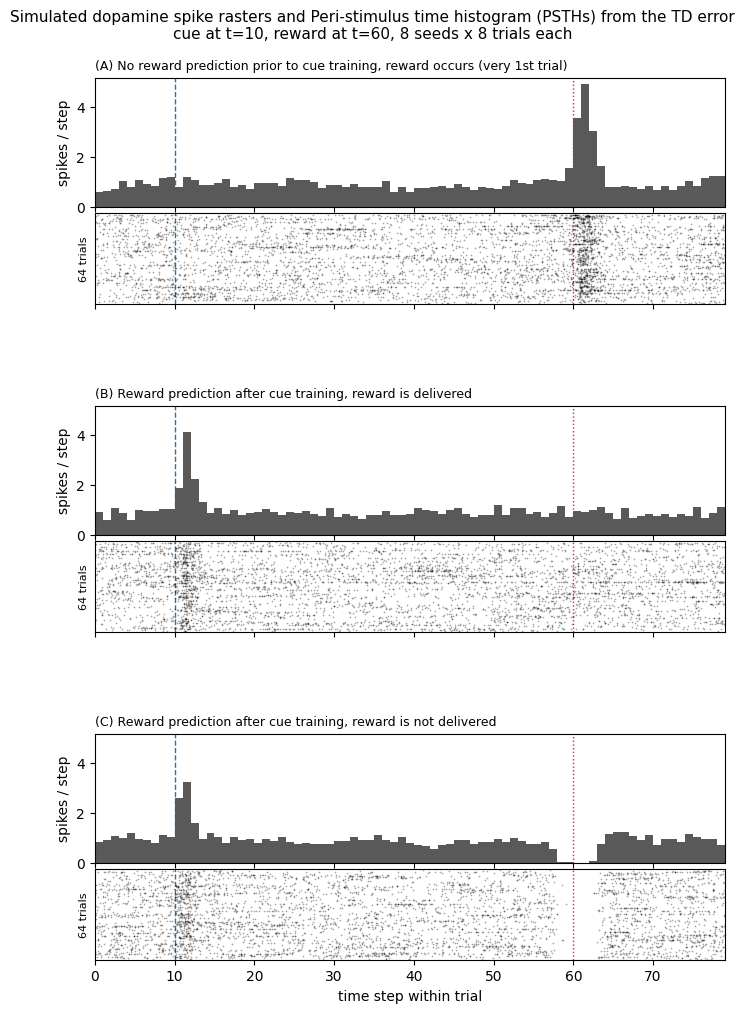

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SUBSTEPS = 8               # sub-samples per time step: finer spike times, curvier PSTH
SPIKE_BASELINE = 0.90      # mean background spikes per time step
SPIKE_GAIN = 8.0           # burst spikes per unit of delta
SPIKE_SUPPRESSION = 3.0    # how hard a negative delta silences the background
SPIKE_DEADZONE = 0.15      # report noise below this does not drive the neuron
BURST_TAU = 0.6            # burst decay constant, in time steps
LATENCY_SD = 0.4           # trial-to-trial response latency jitter, in time steps
PAUSE_STEPS = 2.5          # width of the firing pause caused by a negative delta
GAIN_CV = 0.45             # trial-to-trial variability in burst size
BACKGROUND_TAU = 3.0       # correlation length of background rate drift, in time steps
BACKGROUND_CV = 0.7        # how clumpy the background firing is
ROWS_PER_SEED = 8          # raster rows per trained model
PSTH_BIN = 1.0


def _unit_kernel(values):
    total = values.sum()
    return values / total if total > 0 else values


def burst_kernel(tau=BURST_TAU, substeps=SUBSTEPS):
    """Alpha function: fast rise, slower decay, like a phasic dopamine burst."""
    span = np.arange(0, int(6 * tau * substeps) + 1) / substeps
    return _unit_kernel((span / tau) * np.exp(1.0 - span / tau))


def drift_kernel(tau=BACKGROUND_TAU, substeps=SUBSTEPS):
    reach = int(3 * tau * substeps)
    span = np.arange(-reach, reach + 1) / substeps
    return _unit_kernel(np.exp(-0.5 * (span / tau) ** 2))


def _smooth(values, kernel, causal=False, pad_mode="edge"):
    if causal:
        return np.convolve(values, kernel)[: values.size]
    pad = kernel.size // 2
    padded = np.pad(values, pad, mode=pad_mode)
    return np.convolve(padded, kernel, mode="same")[pad : pad + values.size]


def pause_kernel(width=PAUSE_STEPS, substeps=SUBSTEPS):
    """Max-normalised, so a negative delta keeps its depth while spreading in time."""
    reach = int(width * substeps)
    span = np.arange(-reach, reach + 1) / substeps
    shape = np.exp(-0.5 * (span / (width / 2)) ** 2)
    return shape / shape.max()

def trial_spike_times(reported_td_error, rng, burst, drift_shape, pause=None):
    """Spike times for one trial, in units of time steps."""
    if pause is None:
        pause = pause_kernel()
    n_fine = reported_td_error.size * SUBSTEPS
    fine_error = np.repeat(reported_td_error, SUBSTEPS)
    latency = int(round(rng.normal(0.0, LATENCY_SD) * SUBSTEPS))
    excitation = SPIKE_GAIN * np.maximum(fine_error - SPIKE_DEADZONE, 0.0) / SUBSTEPS
    excitation = _smooth(excitation, burst, causal=True)
    excitation = np.roll(excitation, latency)
    if latency > 0:
        excitation[:latency] = 0.0
    elif latency < 0:
        excitation[latency:] = 0.0
    excitation *= rng.gamma(1.0 / GAIN_CV**2, GAIN_CV**2)
    suppression = SPIKE_SUPPRESSION * np.maximum(-fine_error - SPIKE_DEADZONE, 0.0)
    suppression = np.roll(_smooth(suppression, pause), latency)
    depression = np.clip(1.0 - suppression, 0.0, 1.0)
    # white noise must be zero-padded: edge padding replicates a random endpoint
    drift = _smooth(rng.standard_normal(n_fine), drift_shape, pad_mode="constant")
    drift /= drift.std() or 1.0
    background = (SPIKE_BASELINE / SUBSTEPS) * np.exp(
        BACKGROUND_CV * drift - 0.5 * BACKGROUND_CV**2
    )
    rate = np.maximum(background * depression + excitation, 0.0)
    counts = rng.poisson(rate)
    fine_index = np.repeat(np.arange(n_fine), counts)
    return (fine_index + rng.random(fine_index.size)) / SUBSTEPS

def simulate_condition(key, runs, rows_per_seed=ROWS_PER_SEED, seed=0, report_noise_sd=None):
    """Raster rows for one Fig. 1 condition; reuses trained weights, resamples report noise."""
    if report_noise_sd is None:
        report_noise_sd = NOISE["report_noise_sd"]
    rng = np.random.default_rng(seed)
    burst = burst_kernel()
    drift_shape = drift_kernel()
    pause = pause_kernel()

    spike_x, spike_y, row = [], [], 0
    for run in runs:
        for _ in range(rows_per_seed):
            reported = run[key] + report_noise_sd * rng.standard_normal(TOTAL_STEPS)
            times = trial_spike_times(reported, rng, burst, drift_shape, pause)
            spike_x.append(times)
            spike_y.append(row + rng.uniform(-0.25, 0.25, times.size))
            row += 1
    return np.concatenate(spike_x), np.concatenate(spike_y), row


def draw_condition_panel(ax_hist, ax_raster, spike_x, spike_y, n_rows, title, bins):
    """PSTH above, spike raster below, both built from the same spike times."""
    counts, _ = np.histogram(spike_x, bins=bins)
    ax_hist.bar(
        bins[:-1],
        counts / n_rows / PSTH_BIN,
        width=PSTH_BIN,
        align="edge",
        color="0.35",
        edgecolor="none",
    )
    ax_hist.set_title(title, loc="left", fontsize=9, pad=6)
    ax_hist.set_ylabel("spikes / step")
    ax_hist.tick_params(labelbottom=False)

    ax_raster.scatter(spike_x, spike_y, s=1.5, c="k", alpha=0.35, linewidths=0)
    ax_raster.set_ylim(-1, n_rows)
    ax_raster.set_yticks([])
    ax_raster.set_ylabel(f"{n_rows} trials", fontsize=8)

    for ax in (ax_hist, ax_raster):
        mark_trial_events(ax)
        ax.set_xlim(0, TOTAL_STEPS - 1)


def plot_spike_rasters(
    runs,
    titles=PANEL_TITLES,
    keys=PANEL_KEYS,
    rows_per_seed=ROWS_PER_SEED,
    figsize=(7.5, 10.5),
):
    """One PSTH + raster pair per Fig. 1 case, on a shared spikes-per-step scale."""
    fig = plt.figure(figsize=figsize)
    outer = fig.add_gridspec(
        len(keys), 1, hspace=0.45, top=0.91, bottom=0.07, left=0.13, right=0.97
    )
    bins = np.arange(0, TOTAL_STEPS + PSTH_BIN, PSTH_BIN)
    hist_axes = []

    for panel, (title, key) in enumerate(zip(titles, keys)):
        spike_x, spike_y, n_rows = simulate_condition(
            key, runs, rows_per_seed=rows_per_seed, seed=panel
        )

        inner = outer[panel].subgridspec(2, 1, height_ratios=[2, 1.4], hspace=0.06)
        ax_hist = fig.add_subplot(inner[0])
        ax_raster = fig.add_subplot(inner[1], sharex=ax_hist)
        hist_axes.append(ax_hist)

        draw_condition_panel(ax_hist, ax_raster, spike_x, spike_y, n_rows, title, bins)

        last = panel == len(keys) - 1
        ax_raster.tick_params(labelbottom=last)
        if last:
            ax_raster.set_xlabel("time step within trial")

    top = max(ax.get_ylim()[1] for ax in hist_axes)
    for ax in hist_axes:
        ax.set_ylim(0, top)

    fig.suptitle(
        "Simulated dopamine spike rasters and Peri-stimulus time histogram (PSTHs) from the TD error\n"
        f"cue at t={LIGHT_CUE_STEP}, reward at t={REWARD_STEP}, "
        f"{len(runs)} seeds x {rows_per_seed} trials each",
        fontsize=11,
        y=0.975,
    )
    return fig, hist_axes


fig, hist_axes = plot_spike_rasters(runs)
plt.show()

# What We Found

The three panels reproduce the qualitative pattern of Fig. 1. The readout printed beneath the trace figure gives, as mean $\pm$ standard deviation across the 8 seeds:

Readout | Value
--|--
naive @ reward | $+1.064 \pm 0.065$
trained @ cue | $+0.889 \pm 0.021$
trained @ reward | $+0.118 \pm 0.047$
omission @ reward | $-0.914 \pm 0.103$

All three of the paper's predictions were reproduced. The naive learner bursts only when the juice arrives. After 650 training trials that burst has moved to the light cue and the juice itself is nearly silent. Withholding the juice leaves the cue burst intact and produces a negative deflection of comparable magnitude at exactly $t=60$, with a flat trace in between: the learner has stored _when_ the reward was due, not merely that one was coming.

The spread across seeds is small relative to the effect sizes, the largest standard deviation is about a tenth of the reward magnitude, so the three-way pattern survives every source of noise we injected.

# Where This Differs from the Paper

- Panel (B) still shows $+0.118$ at $t=60$, and the cue burst reaches only $+0.889$ rather than the full reward magnitude. Both follow from `p_reward_omission = 0.1`: the learner trains on a reward that arrives 90% of the time, so $\hat{V}$ converges to the _expected_ reward rather than to $1$. Re-running with `p_reward_omission = 0.0` gives $+0.995$ at the cue, $+0.017$ at the reward, and $-1.007$ on omission, which is the paper's middle panel. The gap is a consequence of the non-determinism we chose to add, not an error in the learner.

- Fig. 1 (top) is labelled "(No CS)"; no cue is presented at all. The histogram is aligned on the reward rather than on the cue. Ours presents the cue at $t=10$ with untrained weights, which is the first trial of training rather than an unpredicted reward in isolation. Because the initial weights are near zero the cue contributes almost nothing to $\delta$, so the trace looks the same, but the two conditions are not identical.

- The caption of Fig. 3 describes cues at steps 10 _and_ 20 followed by reward at step 60; we kept only the cue at step 10. The body text describes that same figure as predicting reward "20 time steps into the future," which does not agree with its own caption; we followed the caption.

- The paper allows $0 \le \gamma \le 1$, but with 50 steps between cue and reward, discounting destroys the effect the figure exists to show: $\gamma = 0.99$ shrinks the cue burst to $+0.59$, and $\gamma = 0.95$ to $+0.08$. Fig. 3 reports that the weights "eventually all saturate to 1," which implies $\gamma = 1$ there as well.

- The omission dip, $-0.914$, is nearly the mirror image of the naive burst, $+1.064$. A real dopamine neuron cannot fire at a negative rate, so the depression in Fig. 1 (bottom) is bounded below by the basal firing rate. The raster figure reproduces this by suppressing background firing rather than by drawing negative rates, which is why the dip looks shallower than the burst even though the underlying prediction errors are nearly equal and opposite.

# What Didn't Work

- A deterministic TD learner on a complete serial-compound stimulus follows exactly one trajectory. With all four noise magnitudes set to zero, the eight seeds return byte-identical arrays, and the figure shows a single line with all eight per-seed traces hidden beneath it. The seed only buys variation once something in the task or in the report is genuinely stochastic, which is what the four noise sources above are for.

- $\gamma < 1$ is the textbook default and it is the wrong choice here. At a 50-step cue-reward interval the discount factor removes the cue burst almost entirely, so the panel meant to demonstrate the transfer shows nothing worth looking at.

- The burst does not jump to the cue; it drifts backwards through the weight vector one feature at a time, at a rate set by $\alpha$. With $\alpha = 0.1$ the peak of $\delta$ is still at $t=55$ after 50 trials and does not reach the cue until roughly trial 400. That is why `NUM_TRAINING_STEPS = 650` rather than something close to the 50-step width of the stimulus: train for too few trials and panel (B) shows a burst stranded in the middle of the interval, which looks like a bug and is not.

# One Thing to Try Next

Reproduce Fig. 3 instead of Fig. 1: plot $\delta$ as a surface over both time step and trial index, so the burst can be seen migrating from the reward to the cue rather than sampled at three snapshots. `train_and_probe` already accumulates every training trial in `td_errors` and currently returns only row 0, so this needs a plotting function and no new learning code.

That view would also test something the present figure cannot. The paper states that "the timing of reward delivery is learned well before any response transfers to the earliest sensory cue"; in our run the peak of $\delta$ sits at $t=55$ on trial 50 and only arrives at the cue near trial 400. Sweeping $\alpha$ against the cue-reward interval would show whether that backward drift rate is a quantitative prediction of the model or an artefact of the complete serial-compound representation.